In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento dos Dados

In [3]:
dados = pd.read_parquet('Lavras.parquet')

dados.head()

,city_residences,id_emisor,total_calls_make,unique_receivers,IDs_receivers_corr,q_calls_corr,residence_distance_km_corr,calls_duration_total_corr
0,Lavras,6A25BB13E0EB57AF0BC1B12E09066090,3,1,[09733364070D428DB7DB059EB964AEEA],[3],[1.6244811412788938],[8.469999999999999]
1,Lavras,A1F433373241547B7E7D0E4E63A8574F,27,1,[EAFB8A6F8D9AD7E91529F6EF7F15BF2B],[27],[1.6244811412788938],[19.590000000000003]
2,Lavras,C0EE955E574B587D037F1DC493ADDEC4,1,1,[54AAE028CCC31C4B800CB1E7E9799253],[1],[3.0086606658789745],[1.43]
3,Lavras,66406B8907461FBB978468BE0D0E22F1,3,1,[033183C2EE18E03EFDF1083D53EE92B5],[3],[1.5927049003955993],[29.29]
4,Lavras,EB4EF78A3B0BAAD118885F2B93881B5F,22,2,"[3F895921B209C4161B721382802BD3BC, 3DB84B3C732...","[21, 1]","[0.0, 0.0]","[18.19, 0.97]"


# Dicionario inicial de dados

| Coluna | Descricao inferida |
|---|---|
| `city_residences` | Cidade de residencia do emissor. Neste recorte, deve ser Lavras. |
| `id_emisor` | Identificador anonimizado do usuario emissor. |
| `total_calls_make` | Total de chamadas feitas pelo emissor. |
| `unique_receivers` | Quantidade de receptores distintos chamados pelo emissor. |
| `IDs_receivers_corr` | Lista de identificadores anonimizados dos receptores. |
| `q_calls_corr` | Lista com quantidade de chamadas para cada receptor correspondente. |
| `residence_distance_km_corr` | Lista com distancia residencial, em km, entre emissor e receptor correspondente. |
| `calls_duration_total_corr` | Lista com duracao total das chamadas para cada receptor correspondente. |

As colunas com sufixo `_corr` precisam ter o mesmo comprimento linha a linha, pois representam atributos de uma mesma aresta emissor-receptor.

In [4]:
resumo_colunas = pd.DataFrame({
    'tipo': dados.dtypes.astype(str),
    'nulos': dados.isna().sum(),
    'n_unicos': [dados[col].astype(str).nunique() for col in dados.columns],
})
resumo_colunas

,tipo,nulos,n_unicos
city_residences,str,0,1
id_emisor,str,0,2968
total_calls_make,int64,0,234
unique_receivers,int64,0,36
IDs_receivers_corr,object,0,2911
q_calls_corr,object,0,1927
residence_distance_km_corr,object,0,1488
calls_duration_total_corr,object,0,2775


# Estatísticas Descritivas dos Emissores

Aqui olhamos para o comportamento por emissor: volume total de chamadas, diversidade de contatos e concentracao. As medidas em log ajudam porque dados de chamadas geralmente possuem cauda longa.

In [5]:
emissor_cols = ['total_calls_make', 'unique_receivers']
dados[emissor_cols].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
total_calls_make,2968.0,39.405323,53.080334,1.0,1.0,1.0,6.0,20.0,51.0,101.0,144.3,243.99,581.0
unique_receivers,2968.0,4.188679,4.032324,1.0,1.0,1.0,2.0,3.0,5.0,8.0,11.0,20.00,40.0


Text(0, 0.5, 'Frequência')

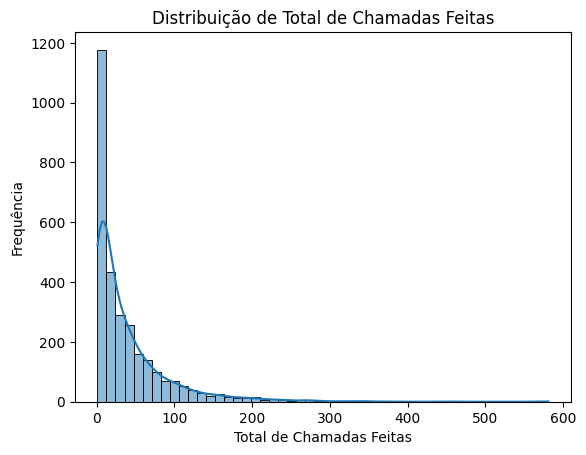

In [ ]:
sns.histplot(dados['total_calls_make'], bins=50, kde=True)
plt.title('Distribuição de Total de Chamadas Feitas')
plt.xlabel('Total de Chamadas Feitas')
plt.ylabel('Frequência')    

Text(0, 0.5, 'Frequência')

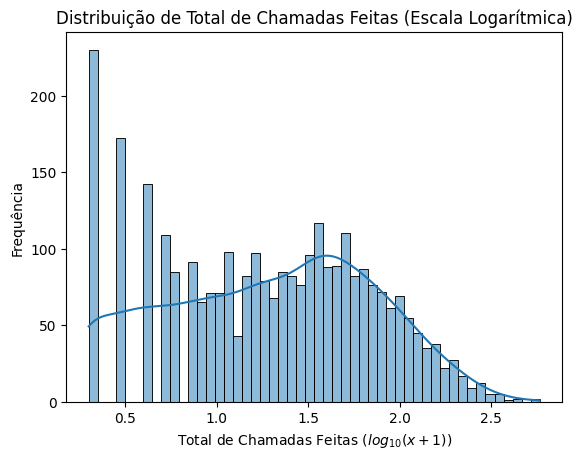

In [40]:
sns.histplot(np.log10(dados['total_calls_make'] + 1), bins=50, kde=True)
plt.title('Distribuição de Total de Chamadas Feitas (Escala Logarítmica)')
plt.xlabel('Total de Chamadas Feitas ($log_{10}(x+1)$)')
plt.ylabel('Frequência')

Text(0.5, 0, 'Número de Receptores Únicos')

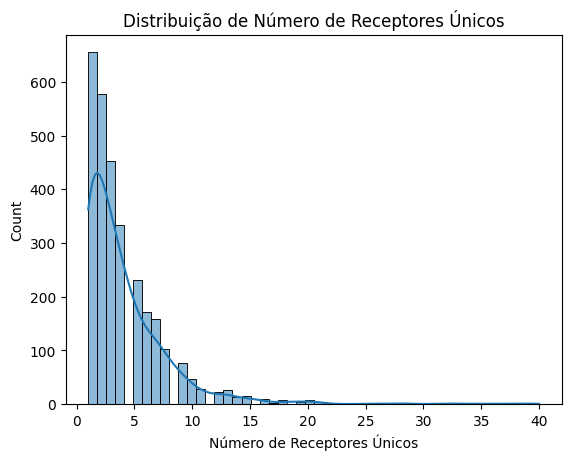

In [14]:
sns.histplot(dados['unique_receivers'], bins=50, kde=True)
plt.title('Distribuição de Número de Receptores Únicos')
plt.xlabel('Número de Receptores Únicos')

Text(0, 0.5, 'Total de Chamadas Feitas')

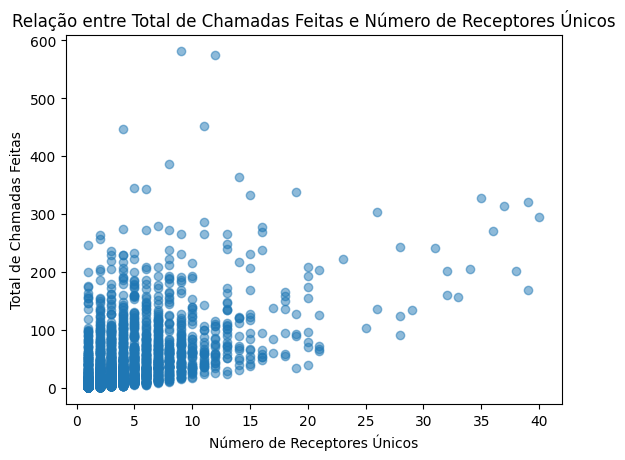

In [21]:
plt.plot(dados['unique_receivers'], dados['total_calls_make'], 'o', alpha=0.5 )
plt.title('Relação entre Total de Chamadas Feitas e Número de Receptores Únicos')
plt.xlabel('Número de Receptores Únicos')
plt.ylabel('Total de Chamadas Feitas')


## Tabela de emissor - receptor

Para aprofundarmos mais nossa análise e prepararmos a base para a análise de sistemas complexos, iremos fazer uma tabela que separará uma coluna para cada chamada, ou seja, criará a relação de um emissor para um receptor.

In [ ]:
linhas = []

for _, row in dados.iterrows():

    source = row['id_emisor']

    receivers = row['IDs_receivers_corr']
    calls = row['q_calls_corr']
    distances = row['residence_distance_km_corr']
    durations = row['calls_duration_total_corr']

    for target, c, d, dur in zip(
        receivers,
        calls,
        distances,
        durations
    ):

        linhas.append({
            'source': source,
            'target': target,
            'calls': c,
            'distance_km': d,
            'duration_total': dur
        })

edges_df = pd.DataFrame(linhas)

In [26]:
edges_df.head()

,source,target,calls,distance_km,duration_total
0,6A25BB13E0EB57AF0BC1B12E09066090,09733364070D428DB7DB059EB964AEEA,3,1.624481,8.47
1,A1F433373241547B7E7D0E4E63A8574F,EAFB8A6F8D9AD7E91529F6EF7F15BF2B,27,1.624481,19.59
2,C0EE955E574B587D037F1DC493ADDEC4,54AAE028CCC31C4B800CB1E7E9799253,1,3.008661,1.43
3,66406B8907461FBB978468BE0D0E22F1,033183C2EE18E03EFDF1083D53EE92B5,3,1.592705,29.29
4,EB4EF78A3B0BAAD118885F2B93881B5F,3F895921B209C4161B721382802BD3BC,21,0.000000,18.19


Text(0.5, 0, 'Duração Total das Chamadas ($log_{10}(x+1)$)')

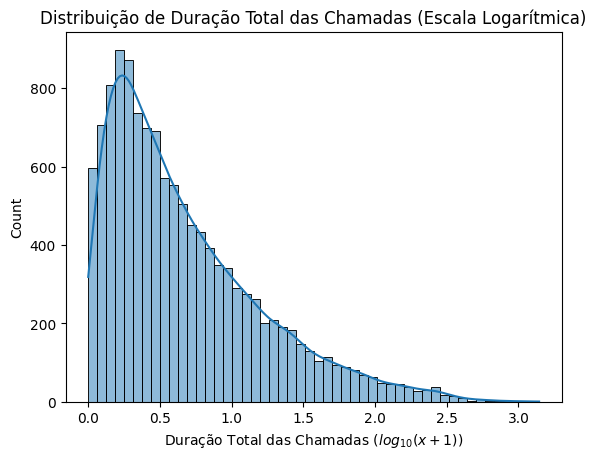

In [29]:
sns.histplot(np.log10(edges_df['duration_total'] + 1), bins=50, kde=True)
plt.title('Distribuição de Duração Total das Chamadas (Escala Logarítmica)')
plt.xlabel('Duração Total das Chamadas ($log_{10}(x+1)$)')

Fica claro que há uma certa tendência para a duração das chamadas, sendo a maioria chamadas relativamente curtas.

Text(0, 0.5, 'Frequência')

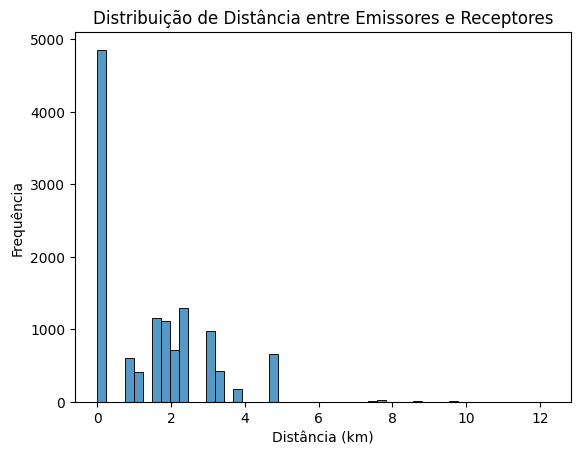

In [31]:
sns.histplot(edges_df['distance_km'], bins=50)
plt.title('Distribuição de Distância entre Emissores e Receptores')
plt.xlabel('Distância (km)')
plt.ylabel('Frequência')

Text(0, 0.5, 'Número de Chamadas')

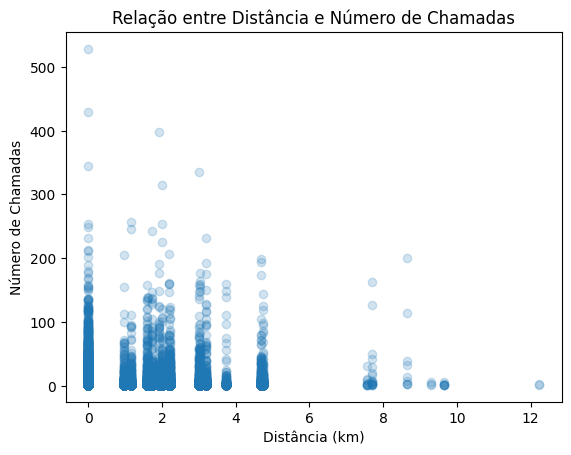

In [43]:
plt.scatter(
    edges_df['distance_km'],
    edges_df['calls'],
    alpha=0.2
)
plt.title('Relação entre Distância e Número de Chamadas')
plt.xlabel('Distância (km)')
plt.ylabel('Número de Chamadas')

In [44]:
x = np.sort(edges_df['calls'])

In [45]:
y = 1.0 - np.arange(len(x)) / len(x)

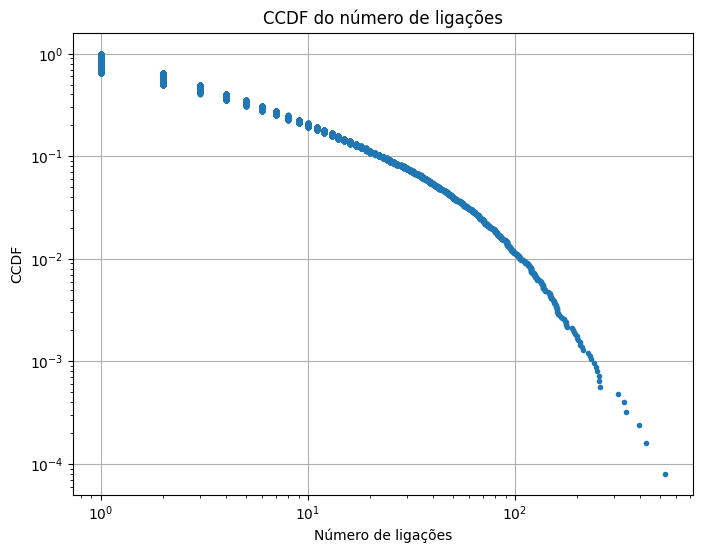

In [46]:
plt.figure(figsize=(8,6))

plt.plot(
    x,
    y,
    marker='.',
    linestyle='none'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Número de ligações')
plt.ylabel('CCDF')

plt.title('CCDF do número de ligações')

plt.grid()

plt.show()

## Pareto de volume de chamadas

A regra 80/20, também chamada de princípio de Pareto, diz que a maioria dos resultados vem de uma pequena parte das causas. Foi criada pelo economista Vilfredo Pareto e é usada para decidir o que é mais importante e para aumentar a produtividade no trabalho e na vida pessoal.

Esta analise mostra quanto do volume total de chamadas e explicado pelos emissores mais ativos. Se a curva acumular rapidamente, poucos usuarios concentram grande parte das chamadas.

In [22]:
pareto = dados[['id_emisor', 'total_calls_make', 'unique_receivers']].sort_values('total_calls_make', ascending=False).reset_index(drop=True)
pareto['rank'] = np.arange(1, len(pareto) + 1)
pareto['pct_emissores'] = pareto['rank'] / len(pareto)
pareto['pct_chamadas_acum'] = pareto['total_calls_make'].cumsum() / pareto['total_calls_make'].sum()
pareto.head(15)

,id_emisor,total_calls_make,unique_receivers,rank,pct_emissores,pct_chamadas_acum
0,645254314639EDACA0DFCD37DCF6A2DD,581,9,1,0.000337,0.004968
1,8DE7ECCB2BD455F7883092DD0567D43B,574,12,2,0.000674,0.009876
2,1A1C2B664417B00DEF20104017E778BD,453,11,3,0.001011,0.013749
3,36FE36ED18B50C18B29D1A16275E64CF,447,4,4,0.001348,0.017571
4,47A1310E83C6871424E6106584B5724A,387,8,5,0.001685,0.020880
5,E70490E25BFF4AEA2C8E966E7F72D4BA,365,14,6,0.002022,0.024001
6,A23B55E0005C0BB7BEE6FC96944140C1,345,5,7,0.002358,0.026951
7,127BC2BA57366C0E58F1DC75427ED796,343,6,8,0.002695,0.029883
8,F0B60CA06AA2036C6B519470EFC25D2A,338,19,9,0.003032,0.032773
9,E7AFDDF4A191642EB2733A355EAC57AB,334,15,10,0.003369,0.035629
